In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df["customerID"].duplicated().sum()

np.int64(0)

In [8]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df["TotalCharges"].dtype)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

float64
Missing TotalCharges: 11


In [10]:
df = df.dropna(subset=["TotalCharges"])

print("New shape:", df.shape)
print("Missing values:", df["TotalCharges"].isnull().sum())

New shape: (7032, 21)
Missing values: 0


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
print("Contract types:")
print(df["Contract"].value_counts())

print("\nInternet service types:")
print(df["InternetService"].value_counts())

print("\nPayment methods:")
print(df["PaymentMethod"].value_counts())

Contract types:
Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

Internet service types:
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

Payment methods:
PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64


In [13]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100

print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


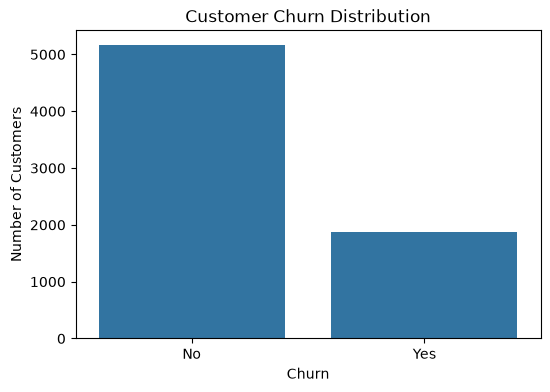

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

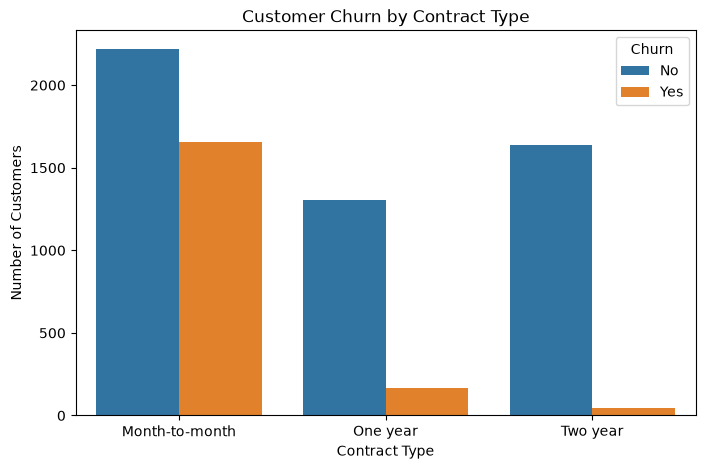

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

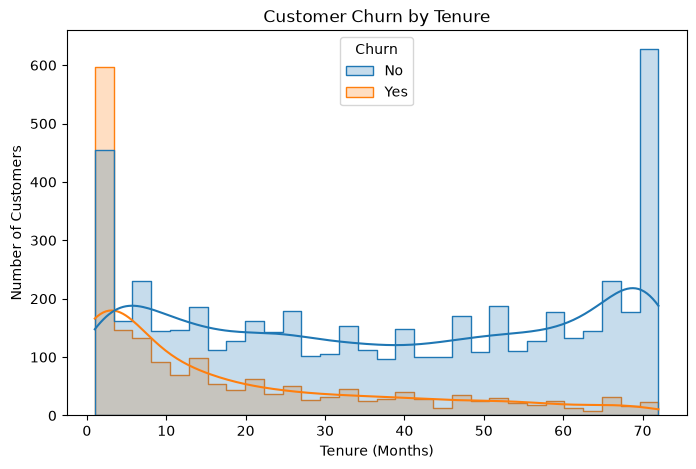

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

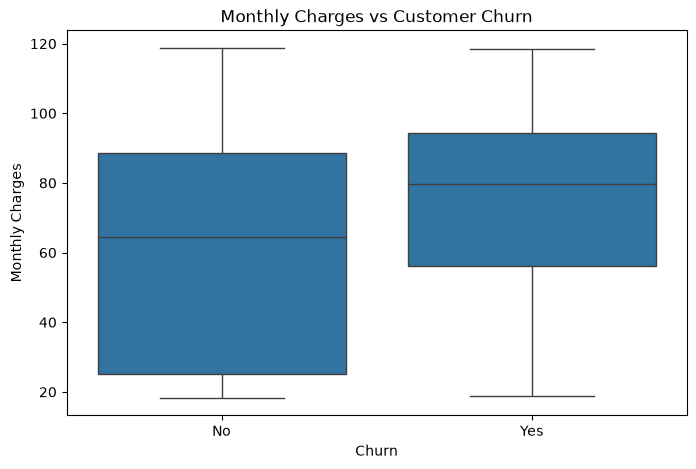

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [18]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [19]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [20]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


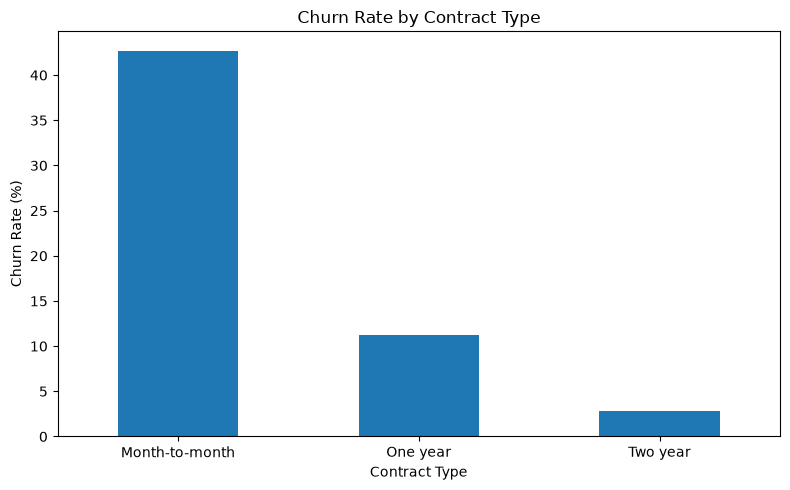

In [21]:
contract_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.650010,61.307408,2555.344141
Yes,17.979133,74.441332,1531.796094


In [23]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"]
)

tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 Months,52.321839,47.678161
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


In [24]:
df = df.drop(columns=["customerID"])

In [25]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (7032, 21)

Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup']

Data types:
gender                   str
SeniorCitizen          int64
Partner                  str
Dependents               str
tenure                 int64
PhoneService             str
MultipleLines            str
InternetService          str
OnlineSecurity           str
OnlineBackup             str
DeviceProtection         str
TechSupport              str
StreamingTV              str
StreamingMovies          str
Contract                 str
PaperlessBilling         str
PaymentMethod            str
MonthlyCharges       float64
TotalCharges         float64
Churn                    str
TenureGroup         category
dtype: object


In [26]:
print("Shape:", df.shape)

Shape: (7032, 21)


In [27]:
X = df.drop(columns=["Churn", "TenureGroup"])
y = df["Churn"].map({"No": 0, "Yes": 1})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


In [28]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\udhay\AppData\Local\Temp\ipykernel_2252\4236146387.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [29]:
print(y.value_counts())
print("\nTarget percentages:")
print(y.value_counts(normalize=True) * 100)

Churn
0    5163
1    1869
Name: count, dtype: int64

Target percentages:
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 19)
Testing data: (1407, 19)


In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [33]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (5625, 45)
Processed testing shape: (1407, 45)


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [35]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [36]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [37]:
y_pred_logistic = logistic_model.predict(X_test_processed)
y_pred_rf = rf_model.predict(X_test_processed)

print("Predictions generated successfully!")

Predictions generated successfully!


In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [39]:
logistic_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_logistic),
    "Precision": precision_score(y_test, y_pred_logistic),
    "Recall": recall_score(y_test, y_pred_logistic),
    "F1 Score": f1_score(y_test, y_pred_logistic),
    "ROC-AUC": roc_auc_score(
        y_test,
        logistic_model.predict_proba(X_test_processed)[:, 1]
    )
}

rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(
        y_test,
        rf_model.predict_proba(X_test_processed)[:, 1]
    )
}

print("Logistic Regression:")
for metric, value in logistic_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nRandom Forest:")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

Logistic Regression:
Accuracy: 0.8038
Precision: 0.6485
Recall: 0.5722
F1 Score: 0.6080
ROC-AUC: 0.8359

Random Forest:
Accuracy: 0.7896
Precision: 0.6345
Recall: 0.4920
F1 Score: 0.5542
ROC-AUC: 0.8140


In [40]:
print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_logistic))

print("\nRANDOM FOREST")
print(classification_report(y_test, y_pred_rf))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [41]:
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Logistic Regression Confusion Matrix:
[[917 116]
 [160 214]]

Random Forest Confusion Matrix:
[[927 106]
 [190 184]]


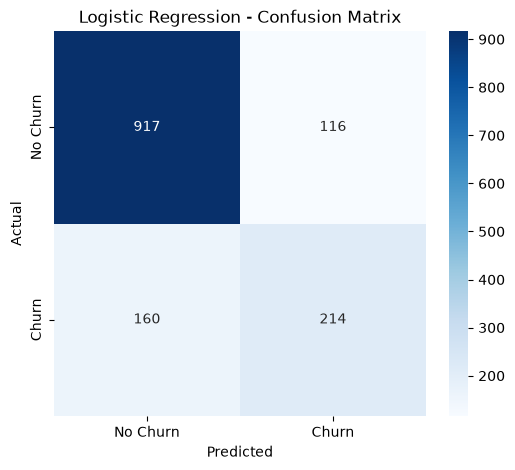

In [42]:
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

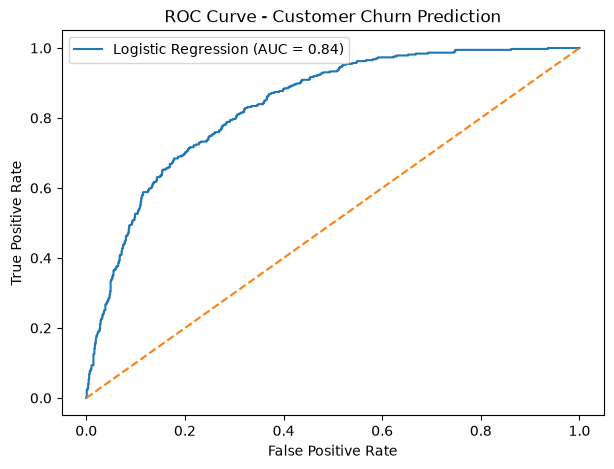

In [43]:
from sklearn.metrics import roc_curve

y_prob_logistic = logistic_model.predict_proba(X_test_processed)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {logistic_metrics['ROC-AUC']:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Customer Churn Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [44]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        logistic_metrics["Accuracy"],
        rf_metrics["Accuracy"]
    ],
    "Precision": [
        logistic_metrics["Precision"],
        rf_metrics["Precision"]
    ],
    "Recall": [
        logistic_metrics["Recall"],
        rf_metrics["Recall"]
    ],
    "F1 Score": [
        logistic_metrics["F1 Score"],
        rf_metrics["F1 Score"]
    ],
    "ROC-AUC": [
        logistic_metrics["ROC-AUC"],
        rf_metrics["ROC-AUC"]
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955,0.835929
1,Random Forest,0.789623,0.634483,0.491979,0.554217,0.813999
